--- Starting Descriptive Analysis: 18 Scenarios vs LSTM ---


C:\Users\E124796\AppData\Local\Temp\2\ipykernel_10372\4217689312.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.boxplot(data=df_melted, x='Scenario', y='Consumption', palette="husl")
c:\Python\Python311\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Python\Python311\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
c:\Python\Python311\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will 

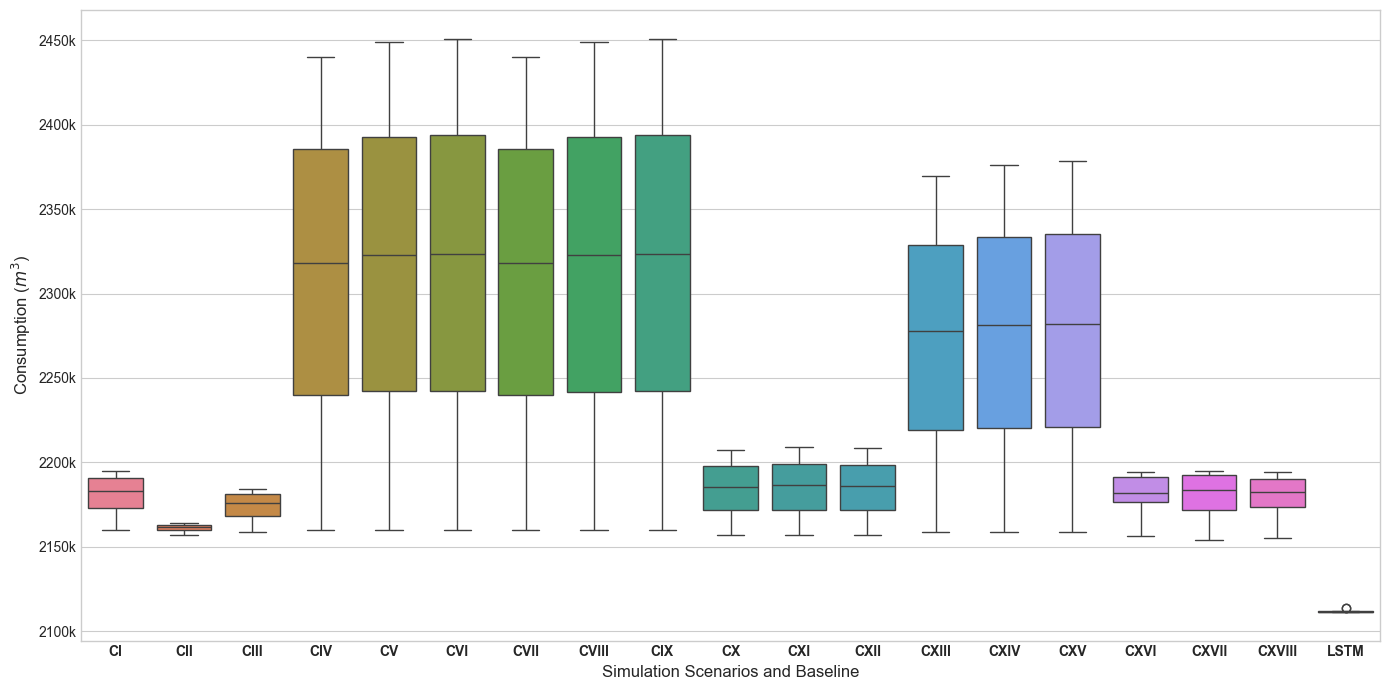

Boxplot saved: E:\Projetos\ABMS-WP\figuras\figure-boxplot-comparison-scenarios-vs-lstm-fig12.pdf


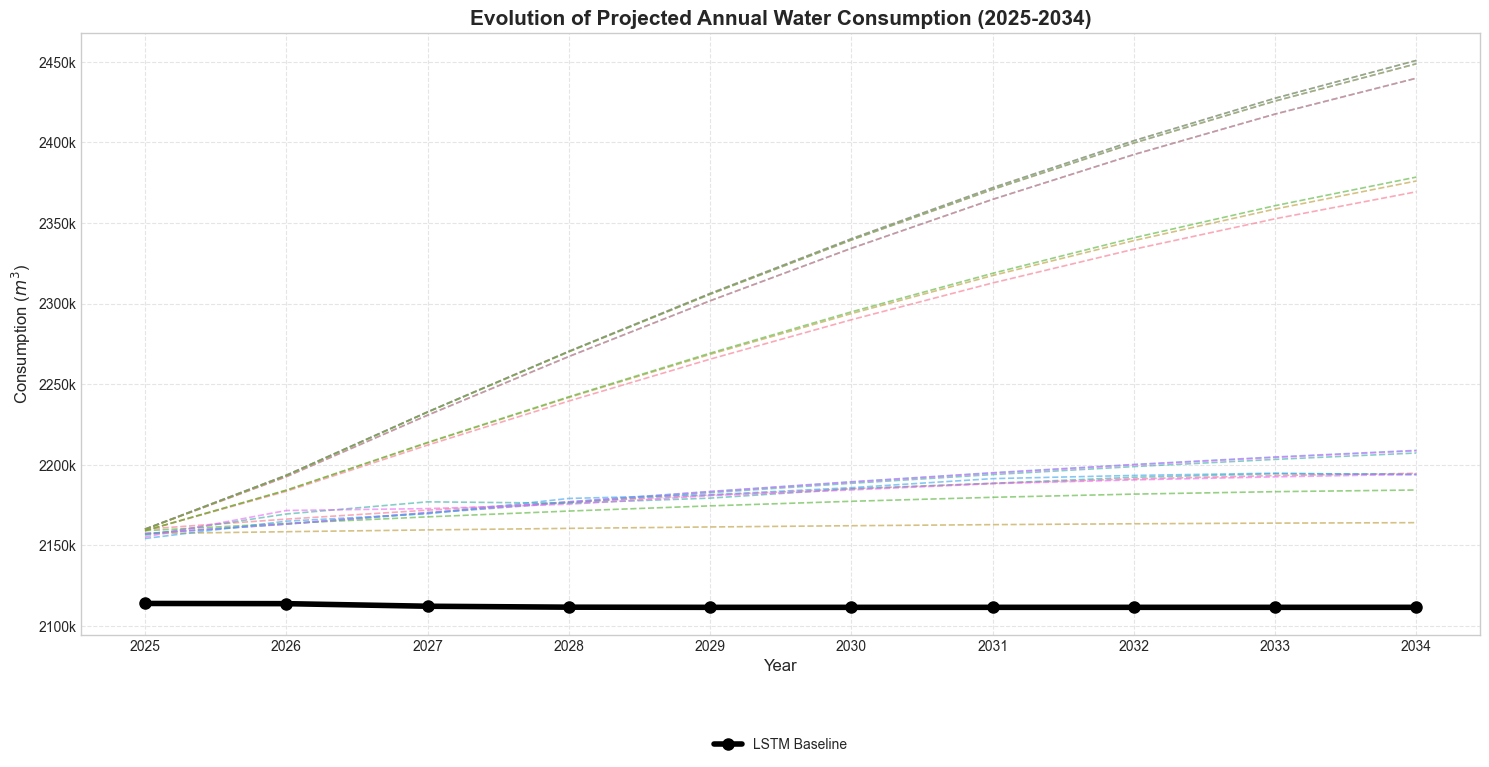

Time Series saved: E:\Projetos\ABMS-WP\figuras\figure-chartline-comparison-scenarios-vs-lstm-fig12.pdf


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import matplotlib.ticker as mticker

# ==========================================
# 1. Configuration and Paths
# ==========================================

# Base Paths
BASE_PATH = 'E:\\Projetos\\ABM-WP' # Currently active path

# Input Files
SCENARIO_FILE = 'consumo_previsto_todos_cenarios.csv'
LSTM_FILE = 'previsoes_futuras_2025_2035.csv'

# Individual Output Filenames
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')
FILE_BOXPLOT = 'figure-boxplot-comparison-scenarios-vs-lstm-fig12.pdf'
FILE_TIMESERIES = 'figure-chartline-comparison-scenarios-vs-lstm-fig12.pdf'

# Directory Structure for data loading
INPUT_DIR_RES = os.path.join(BASE_PATH, 'resultados')
INPUT_DIR_MODELS = os.path.join(BASE_PATH, 'modelos IA')
INPUT_DIR_INC = os.path.join(BASE_PATH, 'includes')

# Style configuration for Elsevier standard
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

def sum_yearly(df, date_col, value_cols):
    """Aggregates monthly data into annual sums."""
    df_year = df.copy()
    df_year['Year'] = df_year[date_col].dt.year
    return df_year.groupby('Year')[value_cols].sum().reset_index()

def main():
    print("--- Starting Descriptive Analysis: 18 Scenarios vs LSTM ---")

    # ==========================================
    # 2. Data Loading and Preparation
    # ==========================================
    
    # Check for scenarios file in multiple locations
    path_scenarios = os.path.join(INPUT_DIR_RES, SCENARIO_FILE)
    if not os.path.exists(path_scenarios):
        path_scenarios = os.path.join(INPUT_DIR_INC, SCENARIO_FILE)
    
    df_scenarios = pd.read_csv(path_scenarios, sep=';', decimal=',')
    
    # Handle Date Construction
    if 'Mes' in df_scenarios.columns and 'Ano' in df_scenarios.columns:
        df_scenarios['Date'] = pd.to_datetime(df_scenarios['Ano'].astype(str) + '-' + 
                                            df_scenarios['Mes'].astype(str) + '-01')
    elif 'Mes_Ano' in df_scenarios.columns:
        df_scenarios['Date'] = pd.to_datetime(df_scenarios['Mes_Ano'], format='%m/%Y')
    
    # Filter scenarios (Period 2025-2034)
    scenario_cols = [c for c in df_scenarios.columns if c not in ['Mes', 'Ano', 'Mes_Ano', 'Date']]
    df_scenarios = df_scenarios[(df_scenarios['Date'] >= '2025-01-01') & (df_scenarios['Date'] <= '2034-12-31')]

    # Load LSTM Forecast
    path_lstm = os.path.join(INPUT_DIR_MODELS, LSTM_FILE)
    df_lstm = pd.read_csv(path_lstm, parse_dates=['Data'])
    df_lstm = df_lstm.rename(columns={'Data': 'Date', 'Valor Previsto': 'LSTM'})
    df_lstm = df_lstm[(df_lstm['Date'] >= '2025-01-01') & (df_lstm['Date'] <= '2034-12-31')]

    # Annual Aggregation
    all_series = scenario_cols + ['LSTM']
    df_combined = pd.merge(df_scenarios, df_lstm[['Date', 'LSTM']], on='Date', how='left')
    df_annual = sum_yearly(df_combined, 'Date', all_series)
    
    # Rename columns to IDs (e.g., CI, CII)
    short_names = {col: (col.split('_')[0] if '_' in col else col) for col in all_series}
    df_annual = df_annual.rename(columns=short_names)

    # Save descriptive statistics
    if not os.path.exists(INPUT_DIR_RES): os.makedirs(INPUT_DIR_RES)
    df_annual.drop(columns='Year').describe().T.to_csv(os.path.join(INPUT_DIR_RES, 'stats_summary_18_scenarios.csv'))

    if not os.path.exists(OUTPUT_DIR): os.makedirs(OUTPUT_DIR)

    # ==========================================
    # 4. Visualization 1: Boxplot
    # ==========================================
    plt.figure(figsize=(14, 7))
    df_melted = df_annual.melt(id_vars='Year', var_name='Scenario', value_name='Consumption')
    
    ax1 = sns.boxplot(data=df_melted, x='Scenario', y='Consumption', palette="husl")
    #plt.title('Distribution of Projected Annual Water Consumption (2025-2034)', fontsize=15, fontweight='bold')
    plt.ylabel('Consumption ($m^3$)', fontsize=12)
    plt.xlabel('Simulation Scenarios and Baseline', fontsize=12)
    
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}k'))
    plt.xticks(fontweight='bold')
    plt.tight_layout()
    
    # Save Boxplot
    path_boxplot = os.path.join(OUTPUT_DIR, FILE_BOXPLOT)
    plt.savefig(path_boxplot, format='pdf', bbox_inches='tight')
    plt.show()
    print(f"Boxplot saved: {path_boxplot}")

    # ==========================================
    # 5. Visualization 2: Time Series
    # ==========================================
    plt.figure(figsize=(15, 8))
    
    # Plot ABM Scenarios
    for column in [c for c in df_annual.columns if c != 'Year' and c != 'LSTM']:
        plt.plot(df_annual['Year'], df_annual[column], linestyle='--', alpha=0.6, linewidth=1.2)
    
    # Plot LSTM Baseline (Highlight)
    plt.plot(df_annual['Year'], df_annual['LSTM'], label='LSTM Baseline', color='black', 
             linewidth=4, marker='o', markersize=8, zorder=10)
    
    plt.title('Evolution of Projected Annual Water Consumption (2025-2034)', fontsize=15, fontweight='bold')
    plt.ylabel('Consumption ($m^3$)', fontsize=12)
    plt.xlabel('Year', fontsize=12)
    
    ax2 = plt.gca()
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}k'))
    ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=6, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2)
    
    # Save Time Series
    path_timeseries = os.path.join(OUTPUT_DIR, FILE_TIMESERIES)
    plt.savefig(path_timeseries, format='pdf', bbox_inches='tight')
    plt.show()
    print(f"Time Series saved: {path_timeseries}")

if __name__ == "__main__":
    main()